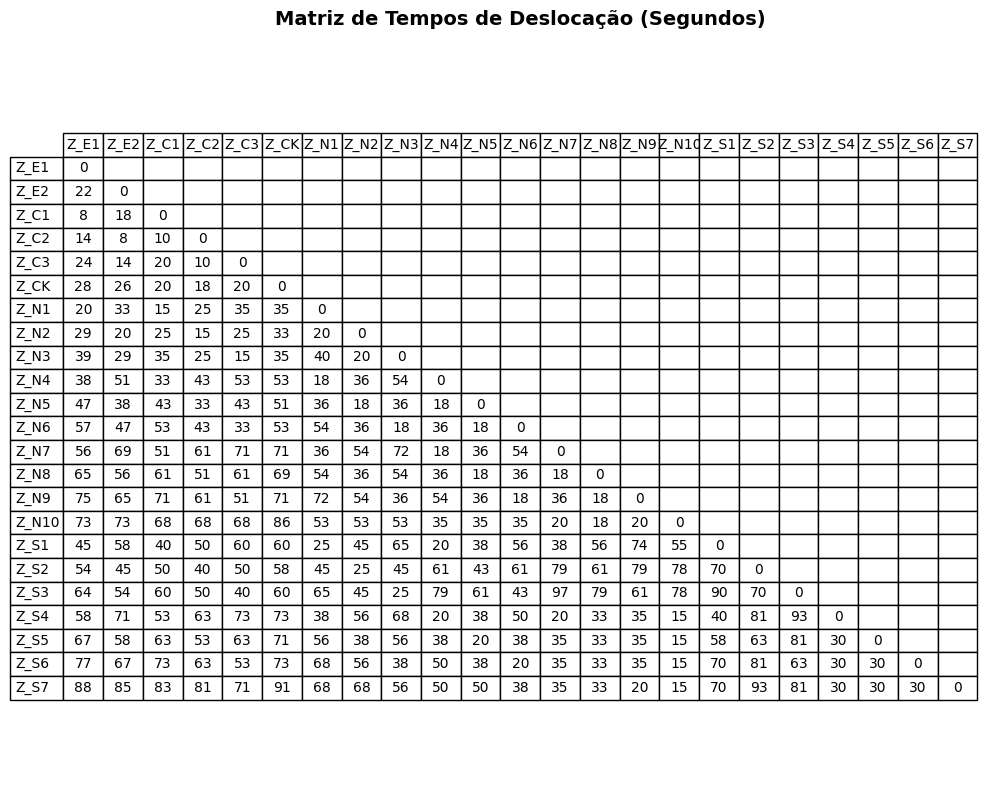

In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from etc.matriztempos import MatrizTempos

def desenhar_imagem_matriz(matriz_obj: MatrizTempos):
    zonas = list(matriz_obj.mapa_zonas.keys())
    
    # 1. Criar e preencher a matriz
    df_matriz = pd.DataFrame(index=zonas, columns=zonas)
    for origem in zonas:
        for destino in zonas:
            df_matriz.loc[origem, destino] = matriz_obj.get_tempo(origem, destino)
            
    # 2. Aplicar a máscara para esconder o triângulo superior
    mascara = np.triu(np.ones(df_matriz.shape, dtype=bool), k=1)
    df_display = df_matriz.astype(int).astype(str)
    df_display = df_display.where(~mascara, "") # Substitui a parte de cima por células vazias
    
    # 3. Desenhar a tabela como uma imagem
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Esconder as margens e eixos típicos de um gráfico
    ax.axis('off')
    ax.axis('tight')
    
    # Criar a tabela passando os dados e as labels
    tabela = ax.table(cellText=df_display.values,
                      rowLabels=df_display.index,
                      colLabels=df_display.columns,
                      cellLoc='center',
                      loc='center')
    
    # Ajustar o estilo da tabela
    tabela.auto_set_font_size(False)
    tabela.set_fontsize(10)
    tabela.scale(1.2, 1.2) # Estica um pouco as células para ficarem mais legíveis
    
    plt.title("Matriz de Tempos de Deslocação (Segundos)", pad=20, fontsize=14, fontweight='bold')
    
    # Podes descomentar a linha abaixo se quiseres que o script guarde logo o PNG:
    # plt.savefig('matriz_tempos.png', dpi=300, bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()

# --- Exemplo de Execução ---
if __name__ == "__main__":
    with open("../data/zones.json", "r", encoding="utf-8") as f:
        info_zonas = json.load(f)
        
    matriz = MatrizTempos(info_zonas["zones"])
    desenhar_imagem_matriz(matriz)

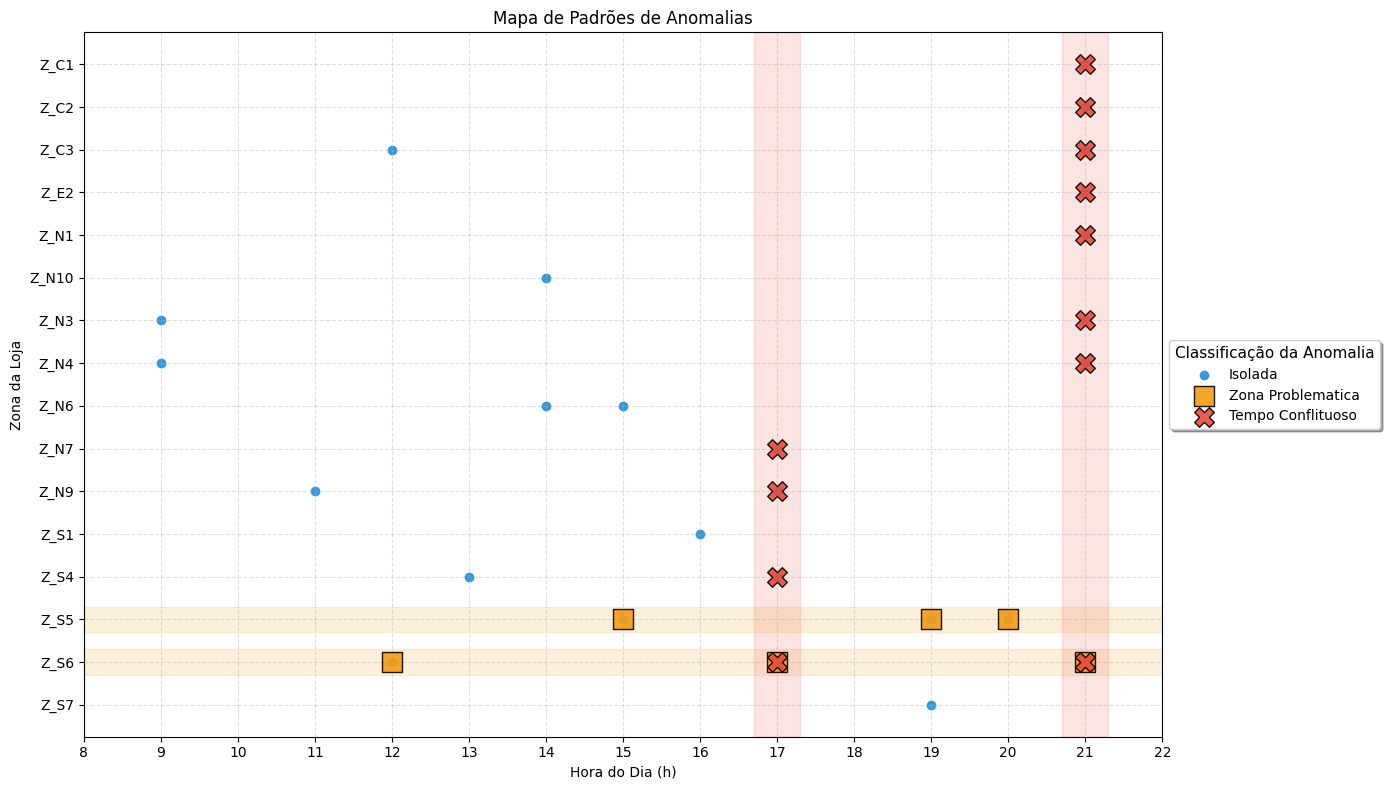

In [9]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

def extrair_grupos_de_anomalias(lista_anomalias, min_threshold=3):
    df = pd.DataFrame(lista_anomalias)
    resultado_final = []
    
    contagem_horas = df['hour_of_day'].value_counts()
    for h in contagem_horas[contagem_horas >= min_threshold].index:
        resultado_final.append(df[df['hour_of_day'] == h].to_dict('records'))
    
    contagem_zonas = df['zone_id'].value_counts()
    for z in contagem_zonas[contagem_zonas >= min_threshold].index:
        resultado_final.append(df[df['zone_id'] == z].to_dict('records'))
        
    return resultado_final



# Carregar os dados
with open("../output/metrics.json", "r", encoding="utf-8") as f:
    lista_original = json.load(f)['anomalies']


df = pd.DataFrame(lista_original)
grupos_extraidos = extrair_grupos_de_anomalias(lista_original, min_threshold=3)

# 2. Descobrir que horas e zonas foram agrupadas pela função
horas_sinalizadas = set()
zonas_sinalizadas = set()

for grupo in grupos_extraidos:
    horas = {d['hour_of_day'] for d in grupo}
    zonas = {d['zone_id'] for d in grupo}
    
    if len(horas) == 1: horas_sinalizadas.add(horas.pop())
    if len(zonas) == 1: zonas_sinalizadas.add(zonas.pop())

# --- CONSTRUÇÃO DO GRÁFICO VISUAL ---
plt.figure(figsize=(14, 8))

# Preparar posições Y
zonas_ordenadas = sorted(df['zone_id'].unique(), reverse=True)
df['y_num'] = df['zone_id'].map(lambda x: zonas_ordenadas.index(x))

# 3. CAMADA 1: Fundo (Todas as anomalias como Isoladas)
plt.scatter(df['hour_of_day'], df['y_num'], c='#3498db', label='Isolada')

# 4. CAMADA 2: Hotspots Persistentes (Zonas)
df_hotspots = df[df['zone_id'].isin(zonas_sinalizadas)]
if not df_hotspots.empty:
    plt.scatter(df_hotspots['hour_of_day'], df_hotspots['y_num'], s=200, 
                c='#f39c12', marker='s', label='Zona Problematica', alpha=0.9, edgecolors='black', zorder=3)
    for z in zonas_sinalizadas:
        plt.axhspan(zonas_ordenadas.index(z) - 0.3, zonas_ordenadas.index(z) + 0.3, color='#f39c12', alpha=0.15, zorder=1)

# 5. CAMADA 3: Macro-Eventos (Horas)
df_macros = df[df['hour_of_day'].isin(horas_sinalizadas)]
if not df_macros.empty:
    plt.scatter(df_macros['hour_of_day'], df_macros['y_num'], s=200, 
                c='#e74c3c', marker='X', label='Tempo Conflituoso', alpha=0.9, edgecolors='black', zorder=4)
    for h in horas_sinalizadas:
        plt.axvspan(h - 0.3, h + 0.3, color='#e74c3c', alpha=0.15, zorder=1)

# --- FORMATAÇÃO E EIXOS ---
plt.title('Mapa de Padrões de Anomalias')
plt.xlabel('Hora do Dia (h)')
plt.ylabel('Zona da Loja')

horas_unicas = sorted(df['hour_of_day'].unique().tolist())
if horas_unicas:
    plt.xticks(range(min(horas_unicas)-1, max(horas_unicas) + 2))
plt.yticks(range(len(zonas_ordenadas)), zonas_ordenadas) 

plt.grid(True, linestyle='--', alpha=0.4, axis='both', zorder=0)

# A legenda já fica perfeita naturalmente, sem necessidade de filtrar duplicados
plt.legend(title='Classificação da Anomalia', title_fontsize='11', loc='center left', 
           bbox_to_anchor=(1, 0.5), frameon=True, shadow=True)

plt.tight_layout()
plt.show()